# Multislice Simulations of h-BN

This notebook reproduces the multislice simulations shown in [publication]. We use the [py_multislice](https://github.com/HamishGBrown/py_multislice) package for image simulation.

The main purpose of these simulations is to determine if an AA' stacked h-NB bilayer will show an intensity difference between columns. AA' stacked bilayer h-BN looks like this

![](figures/figure2/inputs/AAprime_h-BN.jpg)

Imaging of this structure was performed using a scanning transmission electron microscope (STEM) where the image intensity is roughly proportional to the square of the atomic number. Thus, the initial assumption is that an atomic column containing a B and then a N atom will have the same intensity as a column containing a N and then a B atom (i.e. with the order reversed).

Notebook by Ondrej Dyck, April 29, 2025.

## Import Packages

Note we assume that the pyms package has already been installed. Install instructions can be found at the link above.

In [4]:
import pyms
import numpy as np
import matplotlib.pyplot as plt
import torch
#%matplotlib widget
%matplotlib inline

## Import File

In [70]:
# This looks for the local file "h-BN.p1". The p1 file type was produced by Vesta and is compatible with the pyms package.
fname = "figures/figure2/inputs/h-BN.p1"
fname2 = "figures/figure2/inputs/monolayer_h-BN.p1"

structure = pyms.structure.fromfile(fname,temperature_factor_units='urms',atomic_coordinates='fractional')
structure2 = pyms.structure.fromfile(fname2,temperature_factor_units='urms',atomic_coordinates='fractional')

## Quick Plot

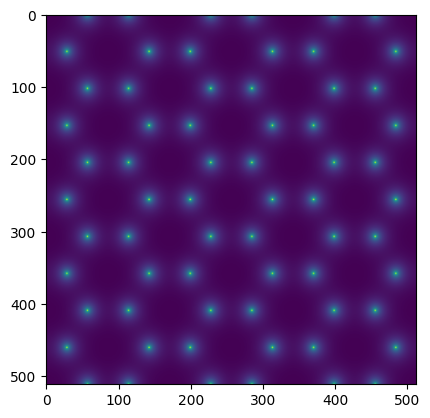

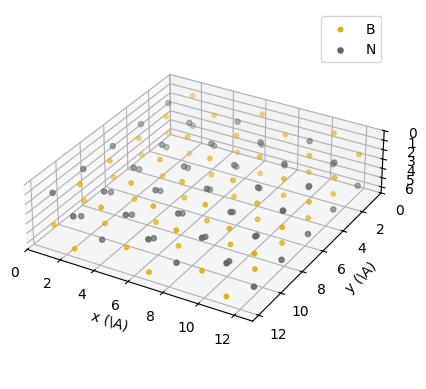

In [72]:
#Create a quickplot of our structure, you can play with scaling using the atomscale parameter
tiling = [5,3]
fig = structure.quickplot(atomscale=2,block=False,tiling=tiling)

# In the following four lines we are changing the orientation of the default 3D view
# so that it will match with the potential. This redrawing does not seem to work in VScode.
#ax = fig.axes[0]
#elev = 85
#azim = 90
#ax.view_init(elev=elev, azim=azim)

pixels = [512,512]

potential = structure.make_potential(pixels,tiling=tiling,displacements=True)

fig2,ax = plt.subplots()
ax.imshow(potential[0].cpu())

## Set Slices

Our structure is very simple so we can manually specify the slices we want.

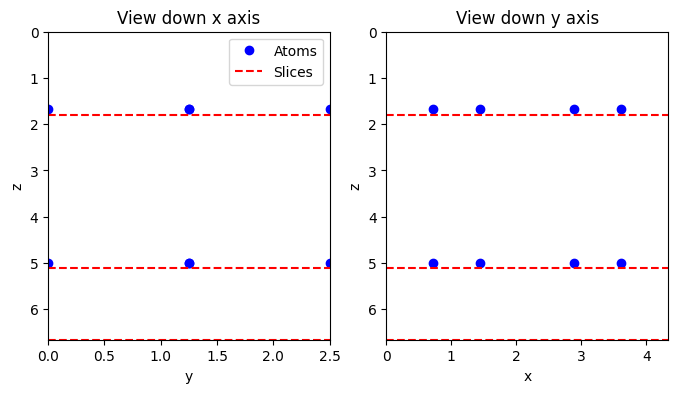

In [74]:
plt.close()
# Select slices under the planes of the atoms
slices = np.asarray([1.8,5.1,structure.unitcell[2]]) /structure.unitcell[2]

# Generate a slicing figure to visualize what has been done
plot = structure.generate_slicing_figure(slices,show=True)

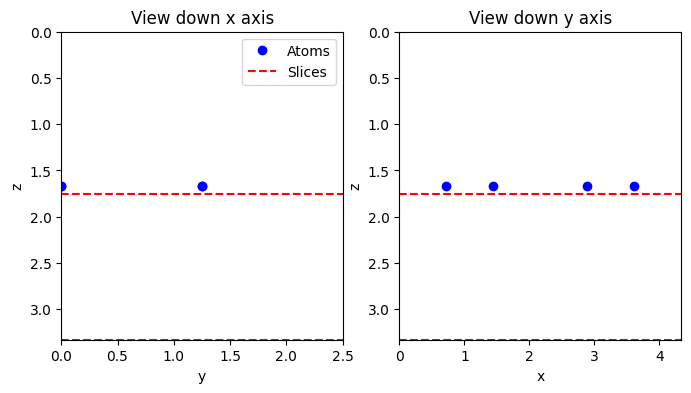

In [80]:
plt.close()
# Select slices under the planes of the atoms
slices2 = np.asarray([1.75,structure2.unitcell[2]]) /structure2.unitcell[2]

# Generate a slicing figure to visualize what has been done
plot = structure2.generate_slicing_figure(slices2,show=True)

## STEM Multislice

In [ ]:
# Use gpu if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Accelerating voltage in eV
eV = 100*(1000)

# Aperature
app = 30

# Material thickness in Angrstroms
thicknesses = [[7]]

# Detector
# This can be a list of lists specifying the min and max values for the detector dimensions in mrad
#                           BF          MAADF         HAADF
# Example: detectors = [[min, max], [min2, max2], [min3, max3]]
# We are only interested in HAADF here
detectors = [[80,150]]

# Defocus -- We want a defocus series so we can see what effect focus has
# This is in Angstroms
df = np.linspace(-40, 40, 11)

# Number of frozen phonon modes
nfph = 40

# calculate
result = pyms.STEM_multislice(
    structure,
    eV,
    app,
    thicknesses,
    nfph=nfph,
    detector_ranges=detectors,
    showProgress=False,
    tiling=tiling,
    gridshape=pixels,
    subslices=[1.0],
    df=df,
    device_type=device)

# Material thickness in Angrstroms
thicknesses = [[4]]

# calculate
result2 = pyms.STEM_multislice(
    structure2,
    eV,
    app,
    thicknesses,
    nfph=nfph,
    detector_ranges=detectors,
    showProgress=False,
    tiling=tiling,
    gridshape=pixels,
    subslices=[1.0],
    df=df,
    device_type=device)

## Plot Simulations

In [88]:
np.shape(result['STEM images'])

(11, 9, 15)

<>:16: SyntaxWarning: invalid escape sequence '\A'
<>:22: SyntaxWarning: invalid escape sequence '\A'
<>:16: SyntaxWarning: invalid escape sequence '\A'
<>:22: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_2106383/953678373.py:16: SyntaxWarning: invalid escape sequence '\A'
  ax.set_title(f'Def. {df[i]} $\AA$')
/tmp/ipykernel_2106383/953678373.py:22: SyntaxWarning: invalid escape sequence '\A'
  ax.set_title(f'Def. {df[i%11]} $\AA$')


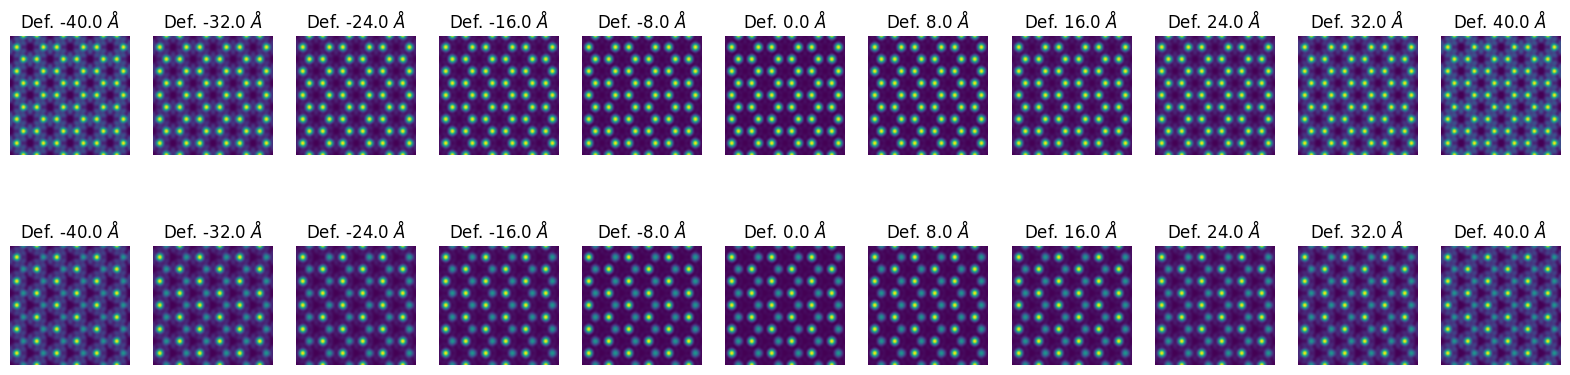

In [113]:
def interp_image(im, tiling, interp_shape=[512,512]):
    return pyms.utils.fourier_interpolate(np.tile(im, tiling), interp_shape)

prof = [] # we are going to plot line profiles next
x=175 # end of line profile
y=100 # height of line profile

ndef, ny, nx = np.shape(result['STEM images'])
ndef2, ny2, nx2 = np.shape(result2['STEM images'])
fig, ax = plt.subplots(figsize=(20,5), ncols=ndef, nrows=2)
for i, ax in enumerate(np.ravel(ax)):
    if i < 11: # the first 11 images are single layer
        im = interp_image(result['STEM images'][i], tiling=tiling)
        prof.append(im[y,:x]) # line profile
        ax.imshow(im)
        ax.set_title(f'Def. {df[i]} $\AA$')
        ax.set_axis_off()
    else: # the rest of the images are bilayer
        im = interp_image(result2['STEM images'][i%11], tiling=tiling) # i%11 is probably not 'elegant' but it works
        prof.append(im[y,:x]) # line profile
        ax.imshow(im)
        ax.set_title(f'Def. {df[i%11]} $\AA$')
        ax.set_axis_off()

plt.savefig('figures/figure2/outputs/Defocus_series.png', bbox_inches='tight', dpi=300)
plt.show()

The first row is the single layer simulation for various defocii. The second row is the double layer.

## Line Profiles

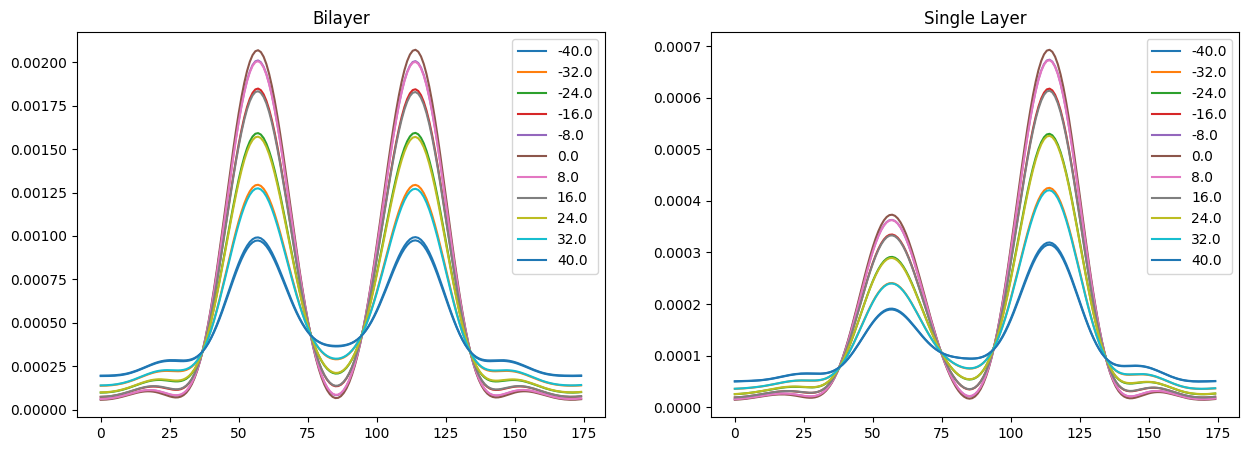

In [114]:
fig, ax = plt.subplots(figsize=(15,5), ncols=2, nrows=1)

for ln, d in zip(prof[:11],df):
    ax[0].plot(ln, label=d)
    ax[0].set_title('Bilayer')
    ax[0].legend()

for ln, d in zip(prof[11:],df):
    ax[1].plot(ln, label=d)
    ax[1].set_title('Single Layer')
    ax[1].legend()

#plt.savefig('Intensity_profiles.svg', bbox_inches='tight')
plt.savefig('figures/figure2/outputs/Intensity_profiles.png', bbox_inches='tight', dpi=200)
plt.show()

What is interesting here is that the bilayer 'Layer 2' simulation shows an intensity difference across a wide range of foci.

Although this is much smaller than the intensity difference between B and N in the single layer, nevertheless it appears to be real.

## Peak Height Difference

Let's quantify the peak height difference we are seeing. In the curves above, it may be hard to pick out the trend as we change defocus.

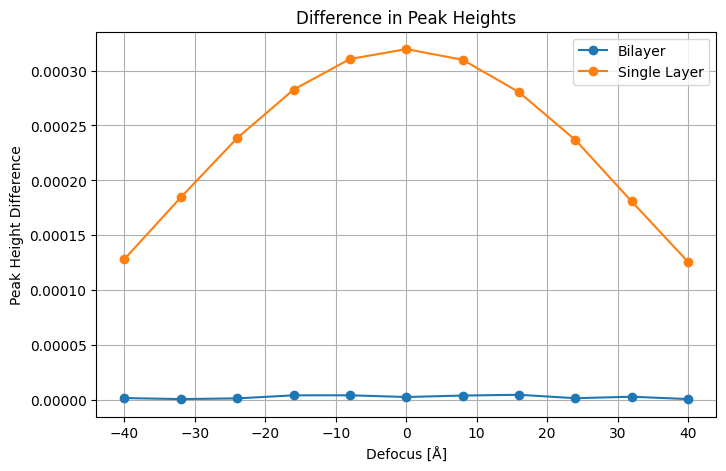

In [115]:
from scipy.signal import find_peaks

# Compute height differences
height_differences = []
for i, ln in enumerate(prof):
    # Find peaks (assuming two prominent Gaussian-like peaks)
    peaks, properties = find_peaks(ln, prominence=0.00005)
    if len(peaks) >= 2:
        # Get heights of the two highest peaks
        peak_heights = ln[peaks]
        # Sort peaks by height to get the two tallest
        peak_heights = np.sort(peak_heights)[-2:]  # Take top 2 peaks
        # Compute absolute difference
        height_diff = abs(peak_heights[1] - peak_heights[0])
        height_differences.append(height_diff)
    else:
        # Handle cases with fewer than 2 peaks
        height_differences.append(np.nan)
        print(f"Warning: Fewer than 2 peaks found in profile {i} (prominence=0.00005)")


# Create plot for height differences
plt.figure(figsize=(8, 5))
plt.plot(df, height_differences[:11], marker='o', linestyle='-', label='Bilayer')
plt.plot(df, height_differences[11:], marker='o', linestyle='-', label='Single Layer')
plt.xlabel(f"Defocus [\u212B]")
plt.ylabel(f"Peak Height Difference")
plt.title("Difference in Peak Heights")
plt.legend()
plt.grid(True)
plt.savefig('figures/figure2/outputs/Peak Difference.png', bbox_inches='tight', dpi=200)
plt.show()

Clearly, the strength of the defocus will change the apparent intensity difference between lattice sites in monolayer h-BN but not in bilayer. We will not attempt to quantify further. What we can say, at this point, is that a B atom followed by a N atom appears no different from a N atom followed by a B atom.

## Simplified Presentation

Here we want to generate the visuals to present our conclusion without bothering with examining the defocus series.

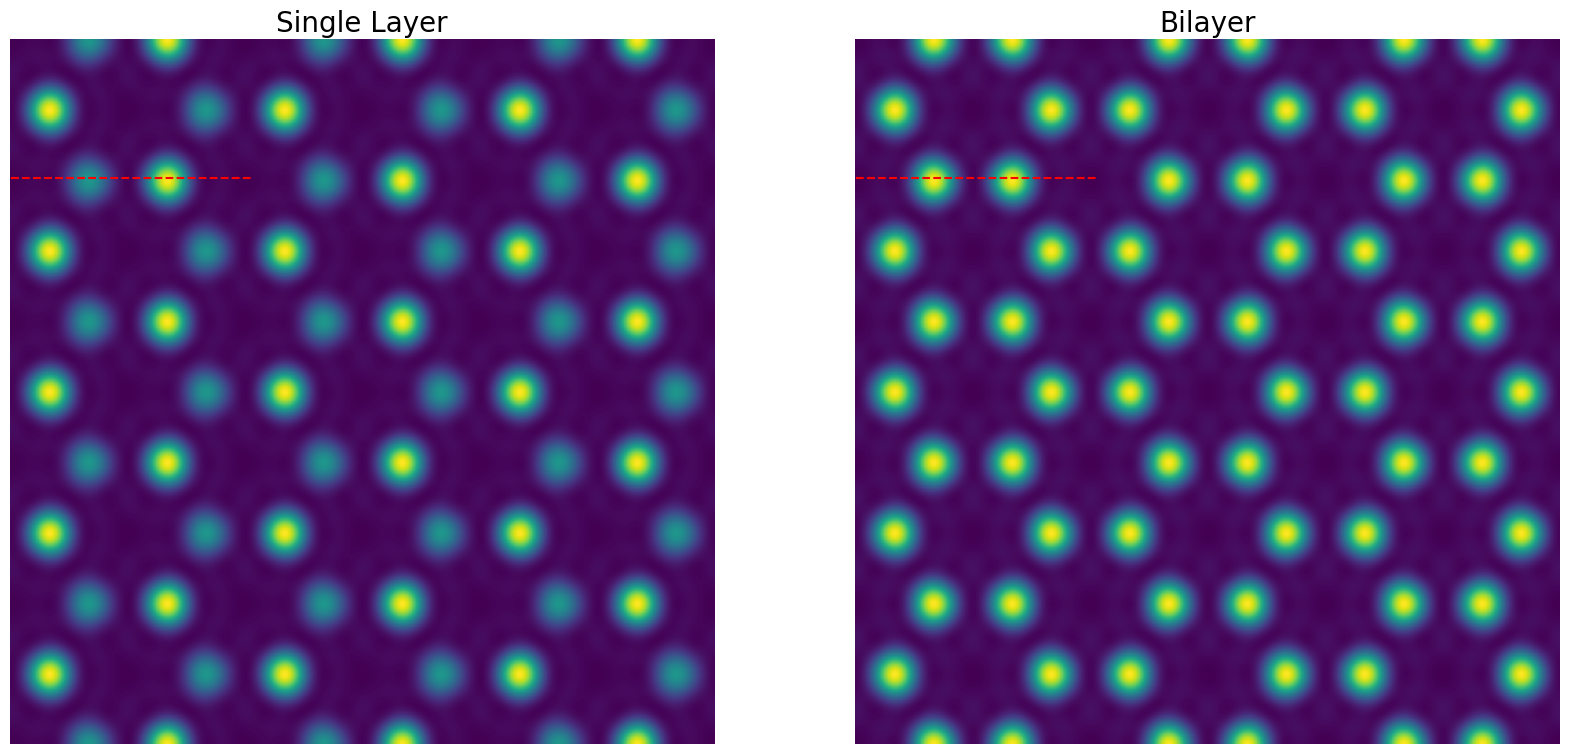

In [116]:
fig, ax = plt.subplots(figsize=(20,20),ncols = 2, nrows=1)

single_layer_im = im = interp_image(result2['STEM images'][6], tiling=tiling)
bilayer_im = im = interp_image(result['STEM images'][6], tiling=tiling)


ax[0].imshow(single_layer_im)
ax[1].imshow(bilayer_im)

ax[0].set_title('Single Layer', fontsize=20)
ax[1].set_title('Bilayer', fontsize=20)
ax[0].set_axis_off()
ax[1].set_axis_off()
ax[0].hlines(y,0,x, linestyle='--', color='red')
ax[1].hlines(y,0,x, linestyle='--', color='red')

plt.savefig('figures/figure2/outputs/Single-Bilayer image comparison.svg', bbox_inches='tight')
#plt.savefig('Single-Bilayer image comparison.png', bbox_inches='tight', dpi=300)
plt.show()

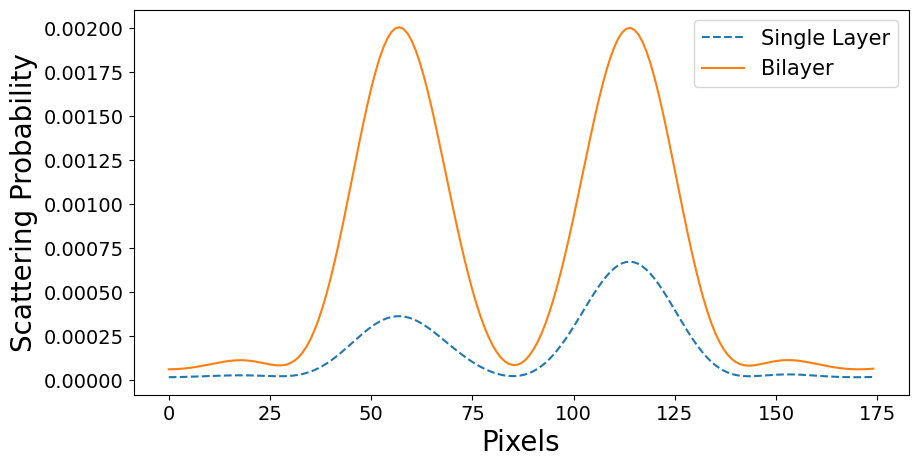

In [117]:
fig, ax = plt.subplots(figsize=(10,5),ncols = 1, nrows=1)
ax.plot(single_layer_im[y,:x], label='Single Layer', linestyle='--')
ax.plot(bilayer_im[y,:x], label='Bilayer')
ax.set_xlabel('Pixels', fontsize=20)
ax.set_ylabel('Scattering Probability', fontsize=20)
ax.tick_params(axis='both', labelsize=14) 
ax.legend(fontsize=15)
plt.savefig('figures/figure2/outputs/Intensity profile comparision.svg', bbox_inches='tight')
plt.show()

## Convergence Check

In the previous simulation we used 40 frozen phonon modes. Here, we want to show that this should be sufficiently converged for the analysis we are conducting. To do this, we will run fifteen separate simulations for a number of different frozen phonon modes and plot the mean absolute difference and standard deviation between the runs. This will give us a quantitative estimate for the variation we expect to see in our simulations. We would like to see it be much lower than the intensity changes we are examining.

In [ ]:
# Parameters
phonons = [1, 2, 5, 10, 20, 30, 40, 50]
num_runs = 15  # Number of duplicate runs per nfph
res = []  # To store results for all runs

# Run simulations for each nfph and each run
for nfph in phonons:
    run_results = []  # Store results for this nfph across runs
    for run in range(num_runs):
        result = pyms.STEM_multislice(
            structure,
            eV,
            app,
            thicknesses,
            nfph=nfph,
            detector_ranges=detectors,
            showProgress=False,
            tiling=tiling,
            gridshape=pixels,
            subslices=[1.0],
            df=0,
            device_type=device
        )
        run_results.append(result)
    res.append(run_results)



## Plot the Convergence Test Results

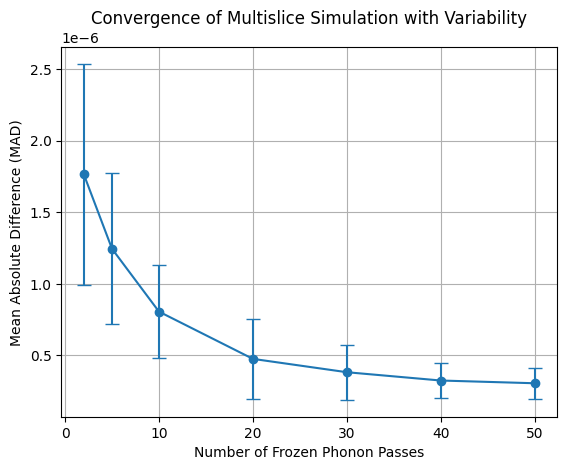

In [119]:
# Compute MAD for each layer separately
mad_per_run = []
for run in range(num_runs):
    images = [res[i][run]['STEM images'][0] for i in range(len(phonons))]
    differences = []
    for i in range(len(phonons) - 1):
        mad = np.mean(np.abs(images[i] - images[i + 1]))
        differences.append(mad)
    mad_per_run.append(differences)

mad_per_run = np.array(mad_per_run)

# Compute statistics
mean_mad = np.mean(mad_per_run, axis=0)
std_mad = np.std(mad_per_run, axis=0, ddof=1)

# Plot
plt.errorbar(phonons[1:], mean_mad, yerr=std_mad, marker='o', capsize=5, linestyle='-')
plt.xlabel("Number of Frozen Phonon Passes")
plt.ylabel("Mean Absolute Difference (MAD)")
plt.title("Convergence of Multislice Simulation with Variability")
plt.grid(True)
#plt.savefig('Multislice Convergence Test.svg', bbox_inches='tight')
#plt.savefig('Multislice Convergence Test.png', bbox_inches='tight', dpi=200)
plt.show()